# Double Machine Learning — Causal Effect of Scholarship on Student Dropout

This notebook extends the **Double Post-LASSO** by applying **Double ML / Partialling-Out** methods.

---

## From Double Post-LASSO to Double ML

Both methods come from the same family of "double de-biasing" estimators, but differ in step 3:

| | **Double Post-LASSO** (notebook 3) | **Double ML / Partialling-Out** (this notebook) |
|---|---|---|
| Step 1 | LASSO(T ~ X) → select $S_T$ | ML model → predict $\hat{m}(X) = \mathbb{E}[D\|X]$ → residuals $\tilde{D}$ |
| Step 2 | LASSO(Y ~ X) → select $S_Y$ | ML model → predict $\hat{\ell}(X) = \mathbb{E}[Y\|X]$ → residuals $\tilde{Y}$ |
| Step 3 | OLS(Y ~ T + $S_T \cup S_Y$) | OLS($\tilde{Y}$ ~ $\tilde{D}$) |

---

## PICO

| Component | Description |
|-----------|-------------|
| **Population** | Higher education students — Portugal |
| **Intervention** | Being a scholarship holder |
| **Control** | Students without scholarship |
| **Outcome** | Dropout (1 = Dropout, 0 = Enrolled/Graduate) |

**Hypothesis:** scholarship → negative effect on dropout probability.

## 1. Imports and preprocessing
### Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    RandomForestRegressor,    RandomForestClassifier,
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, log_loss
from scipy import stats

### Preprocessing
#### Import data

In [18]:
df = pd.read_csv('data.csv', sep=';')
df.columns = df.columns.str.strip()
df['dropout'] = (df['Target'] == 'Dropout').astype(int)
print(f'Shape: {df.shape}')

Shape: (4424, 38)


#### Definition of variables/covariates

In [19]:
treatment = 'Scholarship holder'
outcome   = 'dropout'

socio_demo = [
    'Marital status', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'Educational special needs', 'International',
]
academic = [
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance',
    'Previous qualification', 'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (credited)',    'Curricular units 2nd sem (credited)',
    'Curricular units 1st sem (enrolled)',    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (approved)',    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',       'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
]
macro = ['Unemployment rate', 'Inflation rate', 'GDP']
# EXCLUDED mediators: Debtor, Tuition fees up to date
all_controls = socio_demo + academic + macro

#### Selection of the data

In [20]:
data = df[[treatment, outcome] + all_controls].dropna().reset_index(drop=True)
T = data[treatment].values.astype(float)
Y = data[outcome].values.astype(float)

#### Standardaziation

In [21]:
categorical_cols = [
    'Marital status', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Nacionality', 'Application mode', 'Application order', 'Course',
]
X_raw = data[all_controls].copy()
X_raw[categorical_cols] = X_raw[categorical_cols].astype('category')
X_enc = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_df   = pd.DataFrame(scaler.fit_transform(X_enc), columns=X_enc.columns)
X_df   = X_df.loc[:, X_df.var() > 1e-6]
X      = X_df.values
n, p   = X.shape
print(f'Working sample: {n} obs x {p} features')

Working sample: 4424 obs x 226 features


## 2. Double ML engine — Partialling-Out with K-fold cross-fitting


For each fold k (out-of-fold predictions):

    1- Train ml_l and ml_m on all folds except k
  
    2- Predict Y_hat and T_hat on fold k

Residuals:  

    Y_tilde = Y - Y_hat,   
    
    D_tilde = T - T_hat

ATE: 

    theta = sum(D_tilde * Y_tilde) / sum(D_tilde^2)

### Definition of a function to do double ML with k-fold cross validation


In [22]:
def double_ml(X, Y, T, ml_l, ml_m, n_splits=5, seed=42):
    """
    Double ML Partialling-Out with K-fold cross-fitting.
    Returns: theta, se, pval, ci, resid_D, resid_Y, rmse_l, ll_m
    """
    n = len(Y)
    Y_hat = np.zeros(n)
    T_hat = np.zeros(n)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_idx, val_idx in kf.split(X):
        ml_l_ = clone(ml_l).fit(X[train_idx], Y[train_idx])
        ml_m_ = clone(ml_m).fit(X[train_idx], T[train_idx])
        Y_hat[val_idx] = ml_l_.predict(X[val_idx])
        T_hat[val_idx] = ml_m_.predict_proba(X[val_idx])[:, 1]

    resid_Y = Y - Y_hat
    resid_D = T - T_hat

    # OLS of resid_Y on resid_D (no intercept)
    theta = np.dot(resid_D, resid_Y) / np.dot(resid_D, resid_D)

    # Sandwich SE
    psi = resid_D * (resid_Y - theta * resid_D)
    J   = np.mean(resid_D ** 2)
    se  = np.sqrt(np.mean(psi ** 2) / (n * J ** 2))

    z    = theta / se
    pval = 2 * (1 - stats.norm.cdf(abs(z)))
    ci   = (theta - 1.96 * se, theta + 1.96 * se)

    rmse_l = np.sqrt(mean_squared_error(Y, Y_hat))
    ll_m   = log_loss(T, T_hat)

    return theta, se, pval, ci, resid_D, resid_Y, rmse_l, ll_m

We compare 5 learner combinations, and select the one with the lowest combined nuisance loss (RMSE x Log-Loss).

| Outcome learner (E[Y\|X]) | Treatment learner (E[D\|X]) |
|---------------------------|------------------------------|
| LassoCV                   | LogisticRegressionCV         |
| GradientBoostingRegressor| LogisticRegressionCV         |
| LassoCV                   | GradientBoostingClassifier   |
| GradientBoostingRegressor| GradientBoostingClassifier   |
| RandomForestRegressor    | RandomForestClassifier       |

### Defining our learners

In [23]:
learner_configs = [
    {
        'label': 'LASSO + LogitCV',
        'ml_l': LassoCV(cv=5, max_iter=10000, random_state=42),
        'ml_m': LogisticRegressionCV(cv=5, max_iter=1000, random_state=42),
    },
    {
        'label': 'GBR + LogitCV',
        'ml_l': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
        'ml_m': LogisticRegressionCV(cv=5, max_iter=1000, random_state=42),
    },
    {
        'label': 'LASSO + GBC',
        'ml_l': LassoCV(cv=5, max_iter=10000, random_state=42),
        'ml_m': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    },
    {
        'label': 'GBR + GBC',
        'ml_l': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
        'ml_m': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    },
    {
        'label': 'RF + RF',
        'ml_l': RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
        'ml_m': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    },
]

### Fit models for each pairs of learners

In [24]:
results = []
for cfg in learner_configs:
    print(f'  Fitting {cfg["label"]}...', end=' ', flush=True)
    theta, se, pval, ci, rD, rY, rmse, ll = double_ml(
        X, Y, T, cfg['ml_l'], cfg['ml_m'], n_splits=5
    )
    results.append(dict(
        label=cfg['label'], theta=theta, se=se, pval=pval,
        ci_low=ci[0], ci_high=ci[1],
        rmse_l=rmse, ll_m=ll, combined=rmse*ll,
        resid_D=rD, resid_Y=rY,
    ))
    print(f'ATE={theta:+.4f}  RMSE={rmse:.4f}  LL={ll:.4f}')

  Fitting LASSO + LogitCV... ATE=-0.0515  RMSE=0.3296  LL=0.4743
  Fitting GBR + LogitCV... ATE=-0.0484  RMSE=0.3267  LL=0.4743
  Fitting LASSO + GBC... ATE=-0.0529  RMSE=0.3296  LL=0.4549
  Fitting GBR + GBC... ATE=-0.0549  RMSE=0.3267  LL=0.4549
  Fitting RF + RF... ATE=-0.0591  RMSE=0.3333  LL=0.4951


### Results of each pairs of learners

In [25]:
df_res = pd.DataFrame([{
    'Learner':        r['label'],
    'ATE':            round(r['theta'], 5),
    'SE':             round(r['se'], 5),
    'p-value':        round(r['pval'], 4),
    '95% CI':         f"[{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]",
    'RMSE (ml_l)':    round(r['rmse_l'], 5),
    'LogLoss (ml_m)': round(r['ll_m'], 5),
    'Combined loss':  round(r['combined'], 6),
} for r in results])

best_idx = df_res['Combined loss'].idxmin()
print(df_res.to_string(index=False))
print(f'\nBest learner: {df_res.loc[best_idx, "Learner"]}')

        Learner      ATE      SE  p-value             95% CI  RMSE (ml_l)  LogLoss (ml_m)  Combined loss
LASSO + LogitCV -0.05150 0.01168      0.0 [-0.0744, -0.0286]      0.32960         0.47434       0.156339
  GBR + LogitCV -0.04843 0.01154      0.0 [-0.0710, -0.0258]      0.32666         0.47434       0.154947
    LASSO + GBC -0.05295 0.01170      0.0 [-0.0759, -0.0300]      0.32960         0.45494       0.149948
      GBR + GBC -0.05487 0.01161      0.0 [-0.0776, -0.0321]      0.32666         0.45494       0.148612
        RF + RF -0.05910 0.01083      0.0 [-0.0803, -0.0379]      0.33334         0.49512       0.165042

Best learner: GBR + GBC


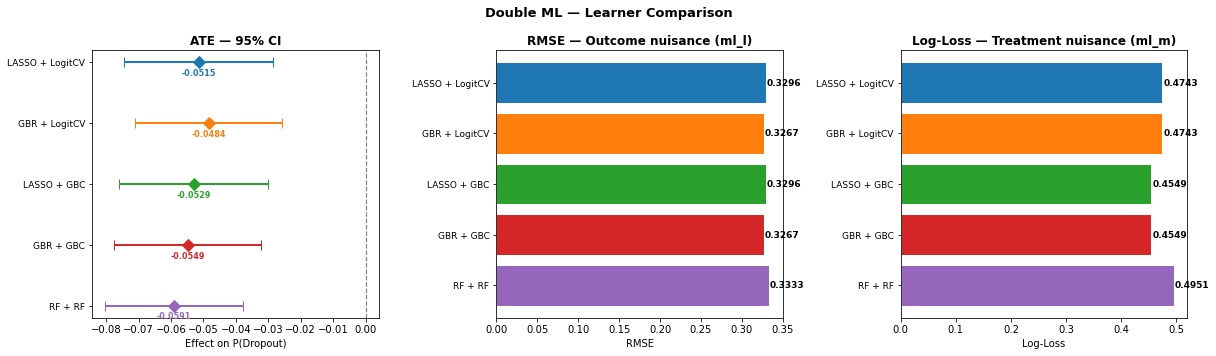

In [26]:
labels = [r['label']  for r in results]
thetas = [r['theta']  for r in results]
ses    = [r['se']     for r in results]
rmses  = [r['rmse_l'] for r in results]
lls    = [r['ll_m']   for r in results]
C      = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Double ML — Learner Comparison', fontweight='bold', fontsize=13)

# ATE panel
ax = axes[0]
for i, (lbl, th, se) in enumerate(zip(labels, thetas, ses)):
    ax.errorbar(th, i, xerr=1.96*se, fmt='D', color=C[i], capsize=5, markersize=8, lw=2)
    ax.text(th, i+0.22, f'{th:+.4f}', ha='center', fontsize=8, color=C[i], fontweight='bold')
ax.axvline(0, color='k', ls='--', lw=1.2, alpha=0.5)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Effect on P(Dropout)')
ax.set_title('ATE — 95% CI', fontweight='bold')

# RMSE ml_l
ax = axes[1]
bars = ax.barh(labels, rmses, color=C[:len(labels)], edgecolor='white')
for bar, v in zip(bars, rmses):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis(); ax.set_yticklabels(labels, fontsize=9)
ax.set_title('RMSE — Outcome nuisance (ml_l)', fontweight='bold')
ax.set_xlabel('RMSE')

# Log-Loss ml_m
ax = axes[2]
bars = ax.barh(labels, lls, color=C[:len(labels)], edgecolor='white')
for bar, v in zip(bars, lls):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis(); ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Log-Loss — Treatment nuisance (ml_m)', fontweight='bold')
ax.set_xlabel('Log-Loss')

plt.tight_layout()
plt.show()

### Results of the best pair of learners

In [27]:
best = results[df_res['Combined loss'].idxmin()]

print('='*55)
print('  DOUBLE ML — BEST LEARNER')
print('='*55)
print(f'  Learner:     {best["label"]}')
print(f'  N:           {n:,}')
print(f'  Controls:    {p} features')
print()
print(f'  ATE:         {best["theta"]:+.4f}')
print(f'  Std. Error:  {best["se"]:.4f}')
print(f'  p-value:     {best["pval"]:.4f}')
print(f'  95% CI:      [{best["ci_low"]:+.4f}, {best["ci_high"]:+.4f}]')
print()
print(f'  RMSE (ml_l): {best["rmse_l"]:.4f}')
print(f'  LogLoss (m): {best["ll_m"]:.4f}')
print('='*55)
print()
print(f'-> Receiving a scholarship reduces dropout by ~{abs(best["theta"])*100:.1f} pp (p < 0.001).')

  DOUBLE ML — BEST LEARNER
  Learner:     GBR + GBC
  N:           4,424
  Controls:    226 features

  ATE:         -0.0549
  Std. Error:  0.0116
  p-value:     0.0000
  95% CI:      [-0.0776, -0.0321]

  RMSE (ml_l): 0.3267
  LogLoss (m): 0.4549

-> Receiving a scholarship reduces dropout by ~5.5 pp (p < 0.001).


### Final comparison with all estimators

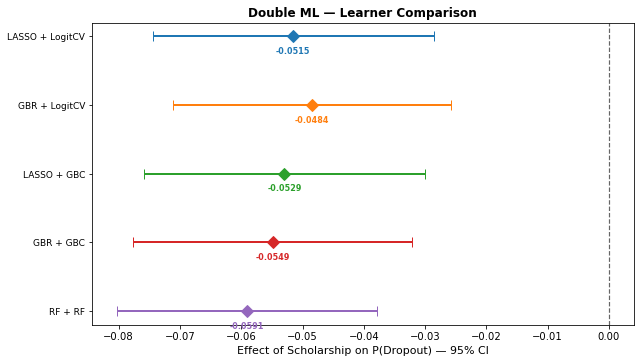

In [28]:
palette = list(plt.cm.tab10.colors)
fig, ax = plt.subplots(figsize=(9, 0.9 + len(results) * 0.85))

for i, r in enumerate(results):
    color = palette[i % len(palette)]
    ax.errorbar(r['theta'], i, xerr=1.96*r['se'], fmt='D', color=color, capsize=5, markersize=8, lw=2)
    ax.text(r['theta'], i+0.25, f'{r["theta"]:+.4f}', ha='center', fontsize=8, color=color, fontweight='bold')

ax.axvline(0, color='k', ls='--', lw=1.2, alpha=0.6)
ax.set_yticks(range(len(results)))
ax.set_yticklabels([r['label'] for r in results], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Effect of Scholarship on P(Dropout) — 95% CI', fontsize=11)
ax.set_title('Double ML — Learner Comparison', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()